# Report_Final_V1 Analysis

Analyzes `tmp/Report_Final_V1_202608290206.csv` — the full-year 2026 `JobHeader` export documented in `docs/discovery/jobheader-table-reference.md` (company/branch/department + `ProductLine` custom field, ~27.8K rows).

Kernel: **Python (cw-learning)**. Source file is gitignored (`tmp/`); this notebook and its saved outputs (aggregate counts/charts only, no raw rows) are safe to commit.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

CSV_PATH = "../tmp/Report_Final_V1_202608290206.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["OpenDate"])
df["OpenMonth"] = df["OpenDate"].dt.to_period("M").dt.to_timestamp()
df.shape

(27813, 10)

## 1. Data overview

In [2]:
df.head()

,JH_JobNum,CompanyCode,CompanyName,BranchCode,BranchName,DeptCode,DeptDescription,OpenDate,ProductLine,OpenMonth
0,VA00000595,ACA,Ben Line Agencies (Canada) Ltd.,AYV,Vancouver,SOA,Ships Agency Accounting,2026-01-01 18:12:00,NaN,2026-01-01
1,VA00000596,ACA,Ben Line Agencies (Canada) Ltd.,AYV,Vancouver,SOA,Ships Agency Accounting,2026-01-01 18:29:00,NaN,2026-01-01
2,VA00000597,ACA,Ben Line Agencies (Canada) Ltd.,AYV,Vancouver,SOA,Ships Agency Accounting,2026-01-01 22:19:00,NaN,2026-01-01
3,B00004233,ACA,Ben Line Agencies (Canada) Ltd.,AYV,Vancouver,CIR,Clearance Import Road,2026-01-02 08:11:00,FS,2026-01-01
4,B00004234,ACA,Ben Line Agencies (Canada) Ltd.,AYV,Vancouver,CFS,Clearance BLFS Sea,2026-01-02 09:01:00,FS,2026-01-01


In [3]:
print(df.dtypes)
print()
print("Date range:", df["OpenDate"].min(), "to", df["OpenDate"].max())
print()
null_pct = (df.isna().mean() * 100).round(1)
null_pct[null_pct > 0]

JH_JobNum                     str
CompanyCode                   str
CompanyName                   str
BranchCode                    str
BranchName                    str
DeptCode                      str
DeptDescription               str
OpenDate           datetime64[us]
ProductLine                   str
OpenMonth          datetime64[us]
dtype: object

Date range: 2026-01-01 09:18:00 to 2026-08-28 23:08:00



ProductLine    9.3
dtype: float64

## 2. Jobs by company

In [4]:
by_company = (
    df.groupby(["CompanyCode", "CompanyName"]).size()
    .reset_index(name="JobCount")
    .sort_values("JobCount", ascending=False)
)
by_company

,CompanyCode,CompanyName,JobCount
6,BCN,Ben Line Agencies (China) Ltd.,4378
26,MVN,"Marine Connections (Vietnam) Co., Ltd.",4265
32,SPH,Simba Logistics (Philippines) Inc.,2505
24,MCN,Marine Connections (Shanghai) Ltd.,2492
8,BID,PT. Bahari Eka Nusantara,2211
13,BMY,Ben Line Agencies (Malaysia) Sdn. Bhd.,2082
15,BSG,Ben Line Agencies (Singapore) Pte Ltd,1077
10,BJP,"Ben Line Agencies (Japan) Co., Ltd.",1070
0,ACA,Ben Line Agencies (Canada) Ltd.,989
11,BKR,Ben Line Agencies Korea Ltd.,849


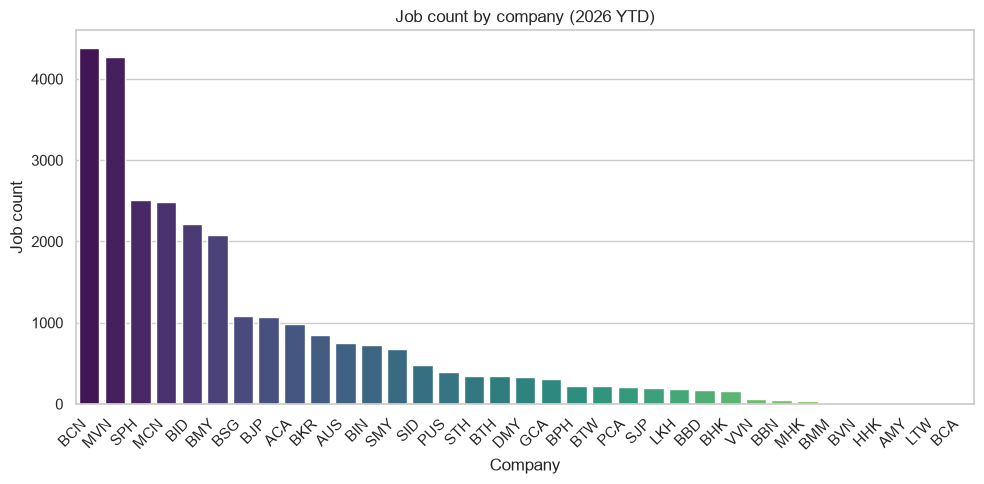

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=by_company, x="CompanyCode", y="JobCount", hue="CompanyCode", legend=False, palette="viridis", ax=ax)
ax.set_title("Job count by company (2026 YTD)")
ax.set_xlabel("Company")
ax.set_ylabel("Job count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Monthly trend — overall

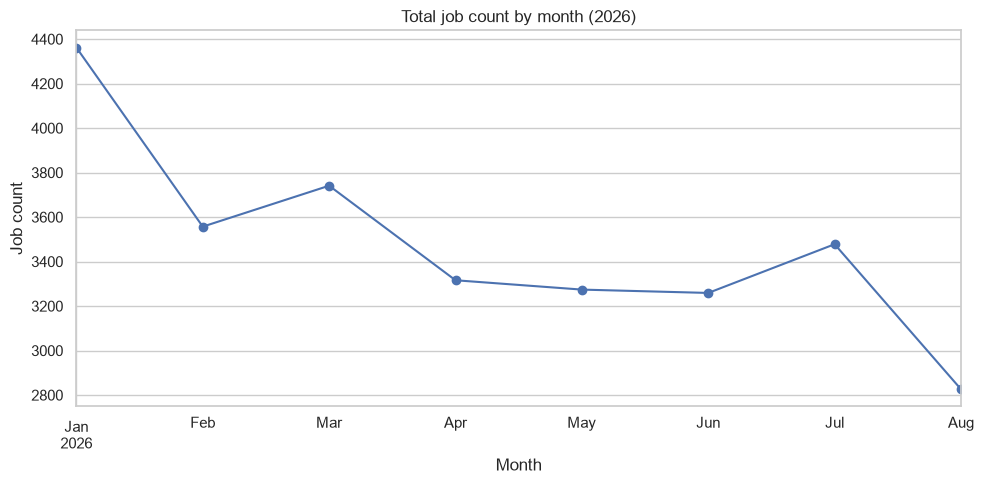

In [6]:
monthly_total = df.groupby("OpenMonth").size()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_total.plot(marker="o", ax=ax)
ax.set_title("Total job count by month (2026)")
ax.set_xlabel("Month")
ax.set_ylabel("Job count")
plt.tight_layout()
plt.show()

## 4. Monthly trend by company (top 6 by volume)

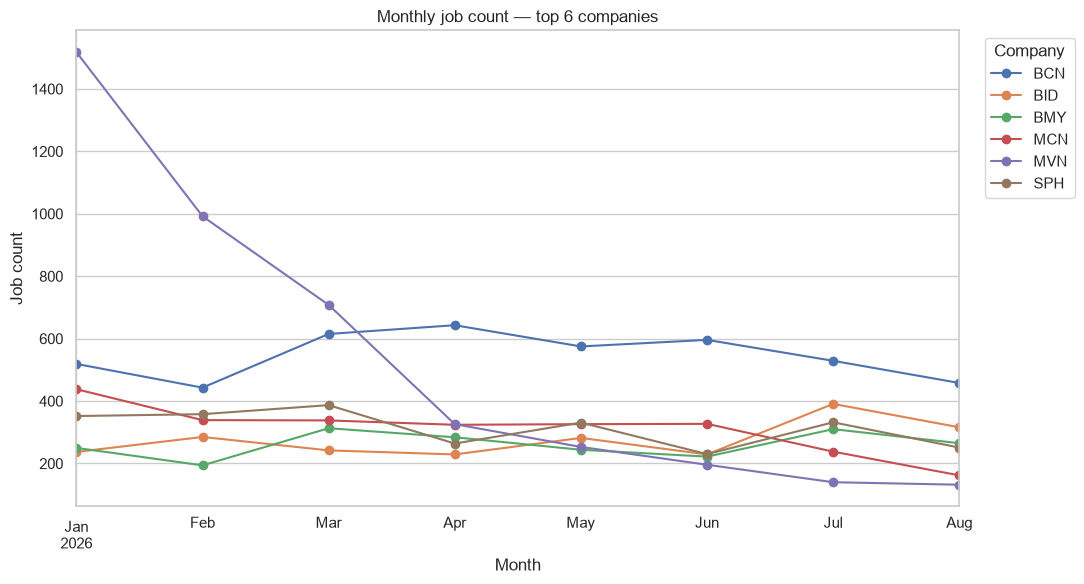

In [7]:
top_companies = by_company["CompanyCode"].head(6).tolist()

monthly_by_company = (
    df[df["CompanyCode"].isin(top_companies)]
    .groupby(["OpenMonth", "CompanyCode"]).size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 6))
monthly_by_company.plot(marker="o", ax=ax)
ax.set_title("Monthly job count — top 6 companies")
ax.set_xlabel("Month")
ax.set_ylabel("Job count")
ax.legend(title="Company", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Jobs by branch (top 15)

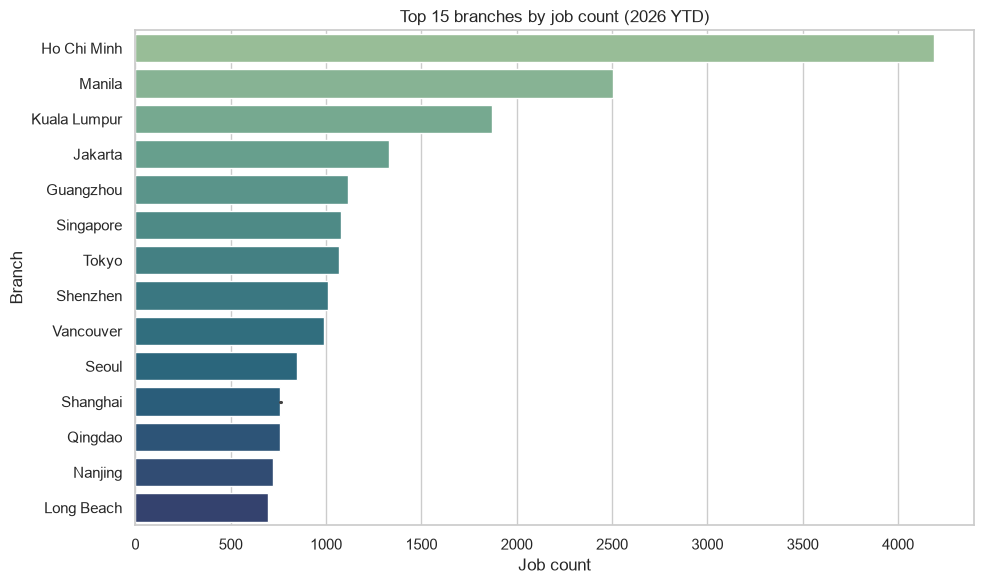

In [8]:
by_branch = (
    df.groupby(["BranchCode", "BranchName"]).size()
    .reset_index(name="JobCount")
    .sort_values("JobCount", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=by_branch, y="BranchName", x="JobCount", hue="BranchName", legend=False, palette="crest", ax=ax)
ax.set_title("Top 15 branches by job count (2026 YTD)")
ax.set_xlabel("Job count")
ax.set_ylabel("Branch")
plt.tight_layout()
plt.show()

## 6. Jobs by department (top 15)

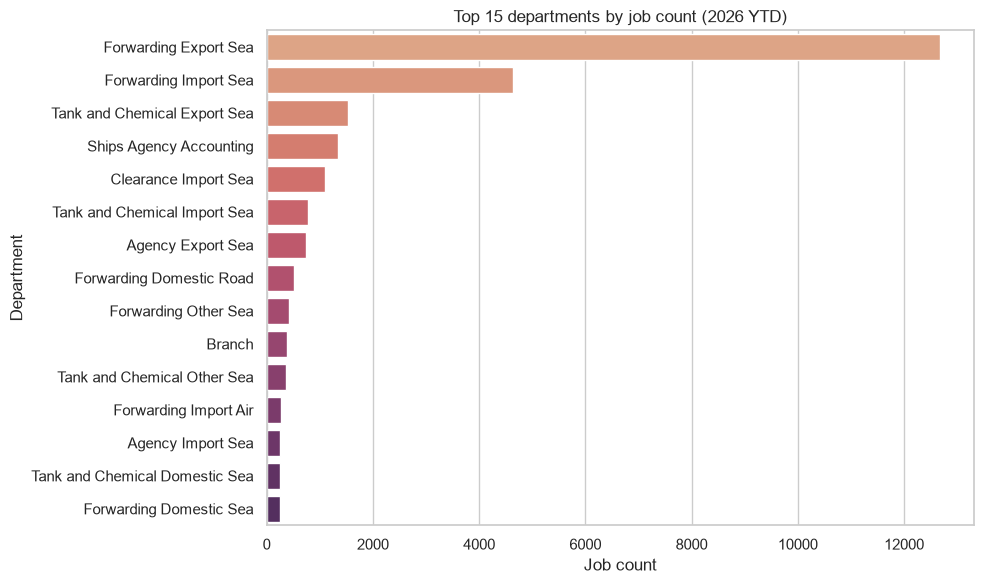

In [9]:
by_dept = (
    df.groupby(["DeptCode", "DeptDescription"]).size()
    .reset_index(name="JobCount")
    .sort_values("JobCount", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=by_dept, y="DeptDescription", x="JobCount", hue="DeptDescription", legend=False, palette="flare", ax=ax)
ax.set_title("Top 15 departments by job count (2026 YTD)")
ax.set_xlabel("Job count")
ax.set_ylabel("Department")
plt.tight_layout()
plt.show()

## 7. Product Line custom field — fill rate & distribution

`ProductLine` is a Custom Field (`GenCustomAddOnValue`, see `docs/discovery/custom-fields-mechanism-reference.md`) — not every job has one set, so the fill rate itself is informative.

In [10]:
fill_rate = df["ProductLine"].notna().mean() * 100
print(f"ProductLine fill rate: {fill_rate:.1f}% ({df['ProductLine'].notna().sum()} of {len(df)} jobs)")

product_line_counts = df["ProductLine"].value_counts()
product_line_counts

ProductLine fill rate: 90.7% (25235 of 27813 jobs)


ProductLine
LCS    16142
FS      5517
TCL     2072
IL      1504
Name: count, dtype: int64

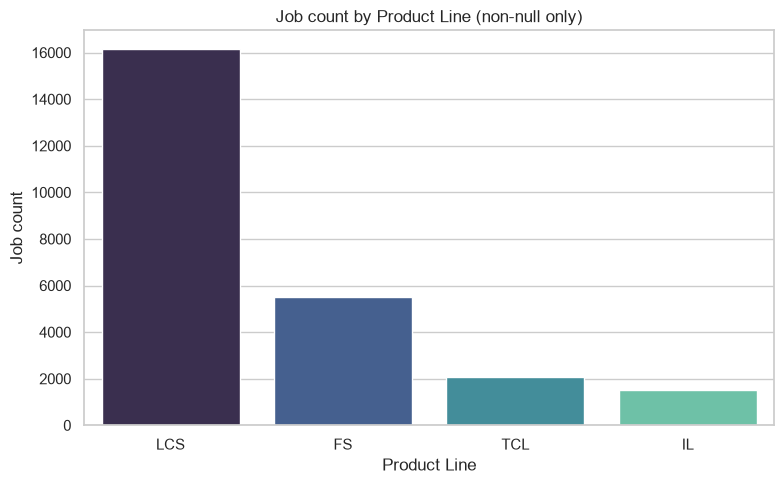

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=product_line_counts.index, y=product_line_counts.values, hue=product_line_counts.index, legend=False, palette="mako", ax=ax)
ax.set_title("Job count by Product Line (non-null only)")
ax.set_xlabel("Product Line")
ax.set_ylabel("Job count")
plt.tight_layout()
plt.show()

## 8. Company × month heatmap

Same data as section 4, as a heatmap — easier to spot a single company's volume collapse (e.g. the MVN pattern from `docs/discovery/job-volume-trend-analysis-2026.md`) across all companies at once.

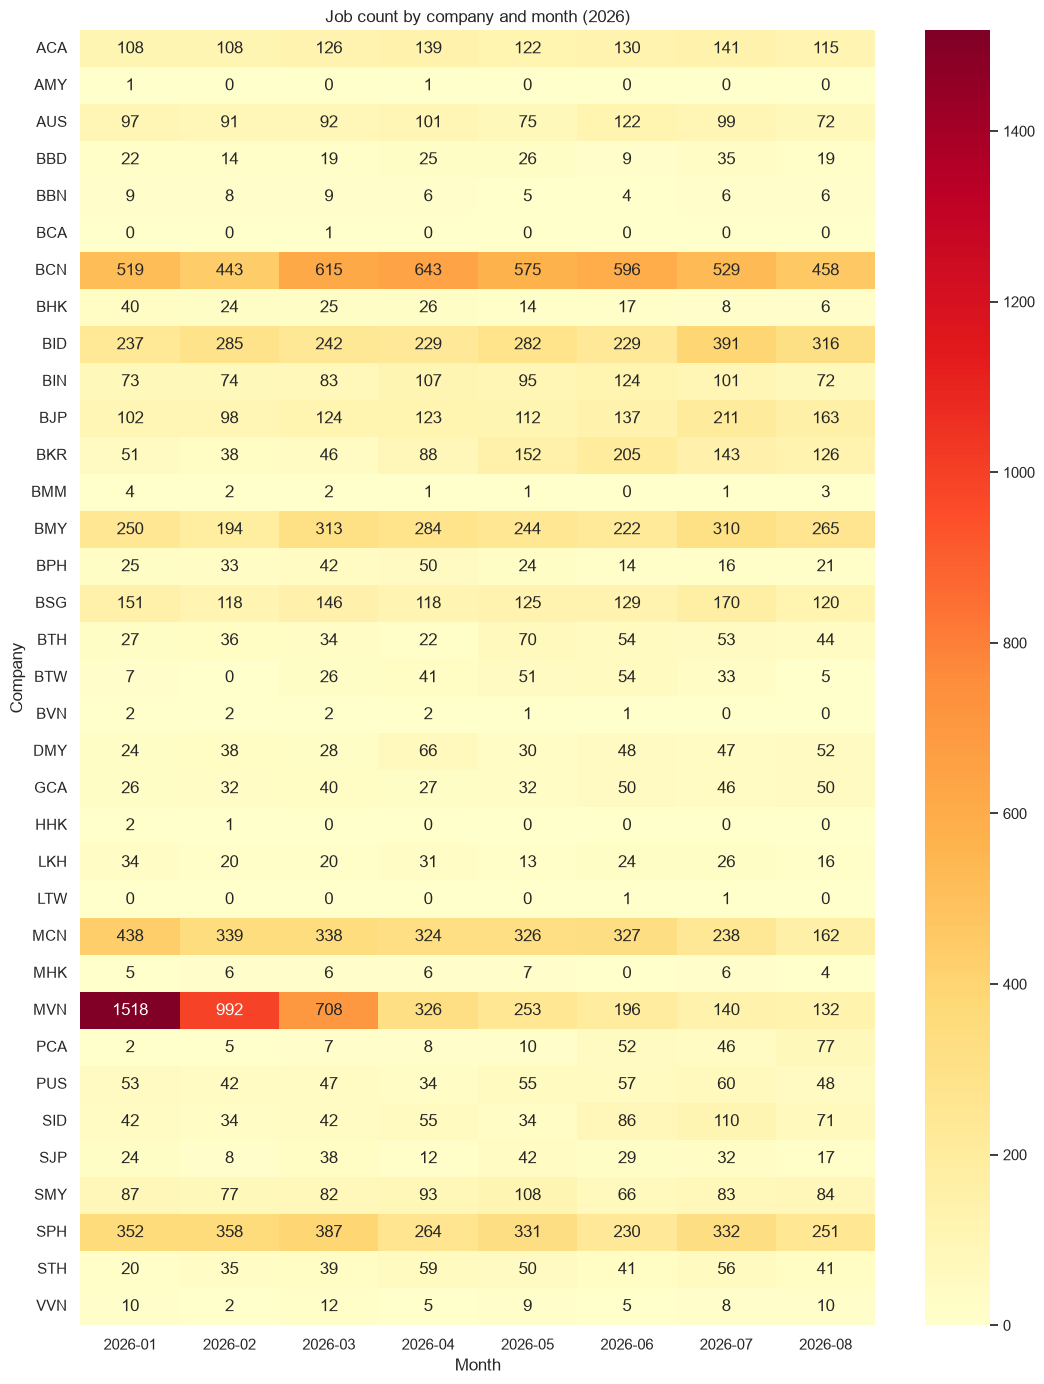

In [12]:
monthly_all_companies = (
    df.groupby(["CompanyCode", "OpenMonth"]).size()
    .unstack(fill_value=0)
)
monthly_all_companies.columns = [c.strftime("%Y-%m") for c in monthly_all_companies.columns]

fig, ax = plt.subplots(figsize=(11, max(4, 0.4 * len(monthly_all_companies))))
sns.heatmap(monthly_all_companies, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Job count by company and month (2026)")
ax.set_xlabel("Month")
ax.set_ylabel("Company")
plt.tight_layout()
plt.show()

## Notes

- `OpenDate` (`JH_A_JOP`) is used for the monthly bucketing here, matching the display/business field the export query orders by — see `docs/discovery/jobheader-table-reference.md` for why the query filters on `JH_SystemCreateTimeUtc` internally but this is statistically equivalent for monthly aggregation.
- Extend this notebook with a `GC_Code`-scoped deep dive if a specific company's trend (e.g. MVN) needs closer investigation.